In [ ]:
from scMM.plot.engine import PlotEngine
from scMM.file.data import CyESIData
import numpy as np
save_path = "/home/zby/scMM/data/algea_results/1mM"
data = CyESIData("/home/zby/scMM/data/algea_results/1mM/algea-0313").normalize()

/home/zby/miniconda3/envs/scMM/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import pandas as pd
adata = data.to_anndata()
idf = pd.read_excel("/home/zby/scMM/data/algea_results/Table.S1.xlsx")
adata.var["name"] = None
for i in range(idf.shape[0]):
    name = idf["Compound name"].values[i]
    obs_mz = idf["Observed mass, m/z"].values[i]
    adata_idx = np.argmin(np.abs(adata.var["mz"].values.astype(float) - obs_mz))
    adata.var.iloc[adata_idx, adata.var.columns.get_loc("name")] = name
print(adata.var)
engine = PlotEngine.from_adata(adata, fig_path_dir=save_path)

/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [5]:
engine.pca(n_components=50)
X = engine.umap(use_pca=True, n_neighbors=15, min_dist=0.7)

/home/zby/miniconda3/envs/scMM/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


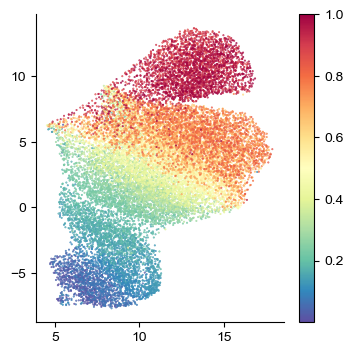

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=data.peak_meta["time"], s=0.2)
plt.colorbar()
plt.show()

In [ ]:
arg = np.argmin(engine.adata.obsm["X_umap"][:,0])
print(arg)
print(engine.adata.obsm["X_umap"][arg, :])

8548
[4.529227  6.2651663]


In [ ]:
# engine.run_palantir(start_idx = 0, plotting=True, cmap="Spectral_r", use_obsm="X_umap", knn=15)

In [ ]:
engine.compute_trajectory(window_size=1000, step_size=300, cell_dist_key="X_umap", 
                          parameterization_key="time", branch_prob_key=None, 
                          store_key="trajectory", plotting=True, cmap="Spectral_r", 
                          title = r"[H$_2$O$_2$] = 30 mM")

In [ ]:
engine.metabolic_velocity(window_size=1500, step_size=500, parameterization_key="time", plot=["field", "speed"],
                          s=1, linewidth=1, color_by="time", cmap="viridis")

In [3]:
engine.adata.var["mz"] = engine.adata.var["mz"].astype(float).round(4)
engine.plot_metabolite_trends(parameterization_key="time", window_size=1000, step_size=300, kernel_stat="median",
                             feature_name_key="mz", plot_top_n=50, cmap="viridis")

In [20]:
engine.plot_metabolite_trends(parameterization_key="time", window_size=1000, step_size=300, kernel_stat="median",
                             feature_name_key="name", metabolite_lists=engine.adata.var["name"].dropna().tolist(), cmap="viridis")

In [ ]:
engine.plot_trend_clusters(metric="correlation", cluster_method="leiden", linewidth=2, resolution=0.3, top_k = 150)

In [ ]:
engine.cluster_cells(method="leiden", n_neighbors=20, resolution=0.3, key_added="leiden_cluster")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

labels = engine.adata.obs["leiden_cluster"]
time = engine.adata.obs["time"]

cluster_num = pd.to_numeric(labels)
order = np.sort(cluster_num.unique())
df = pd.DataFrame({"cluster": cluster_num,"time": time})

plt.figure(figsize=(6, 5))
sns.violinplot(data=df, x="cluster", y="time", order=order, inner="box", cut=0, palette="Set2")
plt.xlabel("Leiden cluster")
plt.ylabel("True time")
plt.title("True time distribution in each Leiden cluster")
plt.tight_layout()
plt.savefig(f"{save_path}/leiden_cluster_time_distribution.svg", bbox_inches="tight")
plt.close()

/tmp/ipykernel_328143/742485224.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="cluster", y="time", order=order, inner="box", cut=0, palette="Set2")


/tmp/ipykernel_360531/2304752776.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  comp_1 = engine.adata.var["mz"][np.argmin(np.abs(engine.adata.var["mz"].astype(float) - comp_1))]
/tmp/ipykernel_360531/2304752776.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  comp_2 = engine.adata.var["mz"][np.argmin(np.abs(engine.adata.var["mz"].astype(float) - comp_2))]


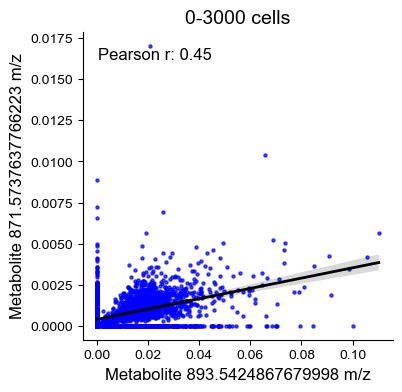

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
comp_1 = 893.5426
comp_2 = 871.5732
comp_1 = engine.adata.var["mz"][np.argmin(np.abs(engine.adata.var["mz"].astype(float) - comp_1))]
comp_2 = engine.adata.var["mz"][np.argmin(np.abs(engine.adata.var["mz"].astype(float) - comp_2))]
data_df = pd.DataFrame(data = engine.adata.X, index = engine.adata.obs.index, columns = engine.adata.var["mz"])
ax = sns.regplot(data_df.iloc[:3000, :],
            x =comp_1, y=comp_2, scatter_kws={"s": 5, "alpha": 0.7, "color": "blue"}, 
            line_kws={"color": "black", "linewidth": 2}, ci=99)
ax.text(0.05, 0.95, f"Pearson r: {data_df.iloc[:3000, :].corr().loc[comp_1, comp_2]:.2f}", 
        transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.set_xlabel(f"Metabolite {comp_1} m/z", fontsize=12)
ax.set_ylabel(f"Metabolite {comp_2} m/z", fontsize=12)
ax.set_title("0-3000 cells", fontsize=14)
plt.savefig("/home/zby/scMM/data/algea_results/1mM/893_871_0_to_3000_cells.svg")

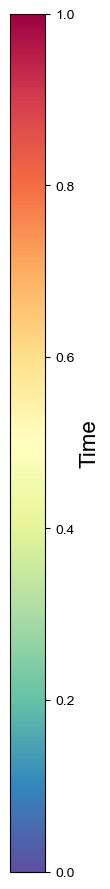

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(1.2, 9))

norm = mpl.colors.Normalize(vmin=0, vmax=1)
cbar = mpl.colorbar.ColorbarBase(
    ax,
    cmap="Spectral_r",
    norm=norm,
    orientation="vertical"
)

cbar.set_label("Time", size=16)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig("bar.svg")

In [ ]:
print(engine.adata.var.shape)
print(engine.adata.uns["metabolite_trends"]["qval"].shape)
print(engine.adata.X.sum(axis=0).shape)

(1026, 1)
(1026,)
(1026,)


In [ ]:
import pandas as pd
df = pd.read_csv("/home/zby/scMM/data/scMM.identifications/Identifications.csv", index_col=0)
df_1 = pd.read_excel("/home/zby/scMM/data/scMM.identifications/identifications_1.xlsx")

In [ ]:
for value in df_1["m/z"]:
    index = np.argmin(np.abs(df.columns.values.astype(float) - value))
    df.iloc[0, index] = df_1[df_1["m/z"] == value]["name"].values[0]
    df.iloc[3, index] = df_1[df_1["m/z"] == value]["molecular formula"].values[0]
    df.iloc[1, index] = df_1[df_1["m/z"] == value]["accurate m/z"].values[0]
    df.iloc[2, index] = df_1[df_1["m/z"] == value]["adduct"].values[0]
    
df = df.T
df["q_value"] = engine.adata.uns["metabolite_trends"]["qval"]
df["detected_rate"] = (engine.adata.X > 0).sum(axis=0) / engine.adata.n_obs

df.to_csv("/home/zby/scMM/data/scMM.identifications/Identifications_annotated.csv")

/tmp/ipykernel_357940/1303338218.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Isocyathisterol' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.iloc[0, index] = df_1[df_1["m/z"] == value]["name"].values[0]
/tmp/ipykernel_357940/1303338218.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'C28H42O2+1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.iloc[3, index] = df_1[df_1["m/z"] == value]["molecular formula"].values[0]
/tmp/ipykernel_357940/1303338218.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'LPI 18:5;O' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.iloc[0, index] = df_1[df_1["m/z"] ==